№1 Задача регрессии **(20 баллов)**

Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/AQp5/X3obvSZRo). Датасет представляет собой набор
признаков, признак в последнем столбце является целевым (его надо прогнозировать).
1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.
2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.
3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).
4. Для предсказания целевого признака постройте следующие модели, используя
библиотеку sklearn:
a. Линейная регрессия LinearRegression()
b. Случайный лес RandomForestRegressor()
c. Метод ближайших соседей KNeighborsRegressor()
d. Метод опорных векторов SVR()
5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.
6. Оцените качество работы моделей. Выведите для каждой модели ее score().
Напишите какая модель дала наилучший результат. Выведите ее значение
feature_importances_

Вся работа должна быть аккуратно оформлена в блокноте и защищена преподавателю.

Коэффициент корреляции Пирсона<br/>
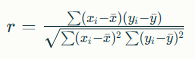

Стандартизация<br/>


Нормализация<br/>
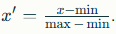

1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.

In [43]:
import pandas as pd                                     # Работа с табличными данными
import numpy as np                                      # Работа с массивами и матрицами
import matplotlib.pyplot as plt                         # Визуализация данных
import seaborn as sns                                   # Визуализация данных
from sklearn.model_selection import train_test_split    # Разделение данных на обучающую и тестовую выборки
from sklearn.linear_model import LinearRegression       # Линейная регрессия
from sklearn.ensemble import RandomForestRegressor      # Случайный лес
from sklearn.neighbors import KNeighborsRegressor       # Метод k-ближайших соседей
from sklearn.svm import SVR                             # Метод опорных векторов
from sklearn.preprocessing import StandardScaler        # Стандартизация данных
from sklearn.metrics import r2_score                    # Коэффициент детерминации R²

# Загрузка и подготовка данных
df = pd.read_csv('dataset_var8_num1.csv', header=None, sep=';')
df

,0,1,2,3,4,5,6,7
0,0.113398,-0.217267,0.215167,-0.016867,-1.064496,0.370968,0.268995,11.886437
1,-0.684545,-0.718804,0.157514,0.025171,0.449468,0.405320,-0.239123,-33.260734
2,0.564893,-0.074579,1.157204,-0.389348,1.734190,NaN,-1.250852,58.674006
3,-0.748604,0.843551,0.436197,-0.899861,0.002277,NaN,1.884221,-34.333124
4,0.308416,2.528793,0.563452,0.088222,0.032436,NaN,-1.643330,29.607853
...,...,...,...,...,...,...,...,...
95,1.215433,1.757035,-0.535669,1.685272,-0.454909,NaN,1.642117,56.204279
96,0.105445,1.066696,0.384910,0.228152,-0.008763,NaN,0.844995,12.984287
97,-0.091576,-1.921410,1.053093,-2.039452,0.401763,NaN,-1.012698,20.837647
98,-0.211409,0.400424,0.146756,0.017062,-0.530500,NaN,2.572902,-5.741275


In [44]:
print('Предварительный анализ и подготовка данных')
print("\n======= Информация о датасете =======")
print(df.info())
print("\n======= Пропуски в данных =======")
print(df.isnull().sum())
print("\n======= Описательная статистика =======") 
df.describe()

Предварительный анализ и подготовка данных

======= Информация о датасете =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       100 non-null    float64
 1   1       100 non-null    float64
 2   2       100 non-null    float64
 3   3       100 non-null    float64
 4   4       95 non-null     float64
 5   5       30 non-null     float64
 6   6       100 non-null    float64
 7   7       100 non-null    float64
dtypes: float64(8)
memory usage: 6.4 KB
None

======= Пропуски в данных =======
0     0
1     0
2     0
3     0
4     5
5    70
6     0
7     0
dtype: int64

======= Описательная статистика =======


,0,1,2,3,4,5,6,7
count,100.000000,100.000000,100.000000,100.000000,95.000000,30.000000,100.000000,100.000000
mean,-0.015087,-0.062730,0.060476,0.022940,0.009851,0.138701,0.062513,1.171854
std,1.079071,0.884791,2.275398,0.934232,1.022725,0.915934,1.002306,72.479434
min,-4.088452,-1.921410,-14.212845,-2.359941,-2.418926,-1.950182,-2.309040,-241.733235
25%,-0.594173,-0.728709,-0.699190,-0.503863,-0.748278,-0.402404,-0.633906,-47.991266
50%,0.060166,-0.048621,0.156478,0.031870,0.032623,0.268823,0.069673,4.931790
75%,0.476788,0.474352,0.820545,0.666486,0.664160,0.590084,0.673443,40.368420
max,2.661735,2.528793,12.410108,2.409821,2.634238,2.361355,2.669669,168.456399


In [45]:
"""
df.info()
Показывается что у 4 столбца 95 non-null, у 5 столбца 30 non-null. Остальные столбцы без пропусков

df.describe()
count подтвержает, что у столбца 4 и 5 есть пропуски.

У целевого столбца (7) слишком большой разброс std = ~72.5 и 
поквинтелям видно широкое распределение, возможны выбросы.

5 столбец имеет слишком много пропусков и исправление средним/медианой, может исказить результат.
Если мы все таки внесем данные, то наша модель модель обучаться на наших догадках,а не на реальных зависимостях.

4 столбец содержит в себе 5 пропусков, поэтому удалить его будет не рациональным решением. 
Более точным будет заполнить пропуски медианой, как более безопасный метод. Выберем его т.к. со средним 
мы исказим распределение признака.
"""

'\ndf.info()\nПоказывается что у 4 столбца 95 non-null, у 5 столбца 30 non-null. Остальные столбцы без пропусков\n\ndf.describe()\ncount подтвержает, что у столбца 4 и 5 есть пропуски.\n\nУ целевого столбца (7) слишком большой разброс std = ~72.5 и \nпоквинтелям видно широкое распределение, возможны выбросы.\n\n5 столбец имеет слишком много пропусков и исправление средним/медианой, может исказить результат.\nЕсли мы все таки внесем данные, то наша модель модель обучаться на наших догадках,а не на реальных зависимостях.\n\n4 столбец содержит в себе 5 пропусков, поэтому удалить его будет не рациональным решением. \nБолее точным будет заполнить пропуски медианой, как более безопасный метод. Выберем его т.к. со средним \nмы исказим распределение признака.\n'

In [46]:
# Анализ пропусков
print("\n======= Обработка пропущенных значений =======")
df = df.drop(columns=[5])

df


======= Обработка пропущенных значений =======


,0,1,2,3,4,6,7
0,0.113398,-0.217267,0.215167,-0.016867,-1.064496,0.268995,11.886437
1,-0.684545,-0.718804,0.157514,0.025171,0.449468,-0.239123,-33.260734
2,0.564893,-0.074579,1.157204,-0.389348,1.734190,-1.250852,58.674006
3,-0.748604,0.843551,0.436197,-0.899861,0.002277,1.884221,-34.333124
4,0.308416,2.528793,0.563452,0.088222,0.032436,-1.643330,29.607853
...,...,...,...,...,...,...,...
95,1.215433,1.757035,-0.535669,1.685272,-0.454909,1.642117,56.204279
96,0.105445,1.066696,0.384910,0.228152,-0.008763,0.844995,12.984287
97,-0.091576,-1.921410,1.053093,-2.039452,0.401763,-1.012698,20.837647
98,-0.211409,0.400424,0.146756,0.017062,-0.530500,2.572902,-5.741275


In [47]:
df = df.fillna(df.median())

In [48]:
print(df.isnull().sum())

0    0
1    0
2    0
3    0
4    0
6    0
7    0
dtype: int64


In [49]:
df

,0,1,2,3,4,6,7
0,0.113398,-0.217267,0.215167,-0.016867,-1.064496,0.268995,11.886437
1,-0.684545,-0.718804,0.157514,0.025171,0.449468,-0.239123,-33.260734
2,0.564893,-0.074579,1.157204,-0.389348,1.734190,-1.250852,58.674006
3,-0.748604,0.843551,0.436197,-0.899861,0.002277,1.884221,-34.333124
4,0.308416,2.528793,0.563452,0.088222,0.032436,-1.643330,29.607853
...,...,...,...,...,...,...,...
95,1.215433,1.757035,-0.535669,1.685272,-0.454909,1.642117,56.204279
96,0.105445,1.066696,0.384910,0.228152,-0.008763,0.844995,12.984287
97,-0.091576,-1.921410,1.053093,-2.039452,0.401763,-1.012698,20.837647
98,-0.211409,0.400424,0.146756,0.017062,-0.530500,2.572902,-5.741275


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.

In [50]:
df.shape

(100, 7)


======= Матрица корреляций =======


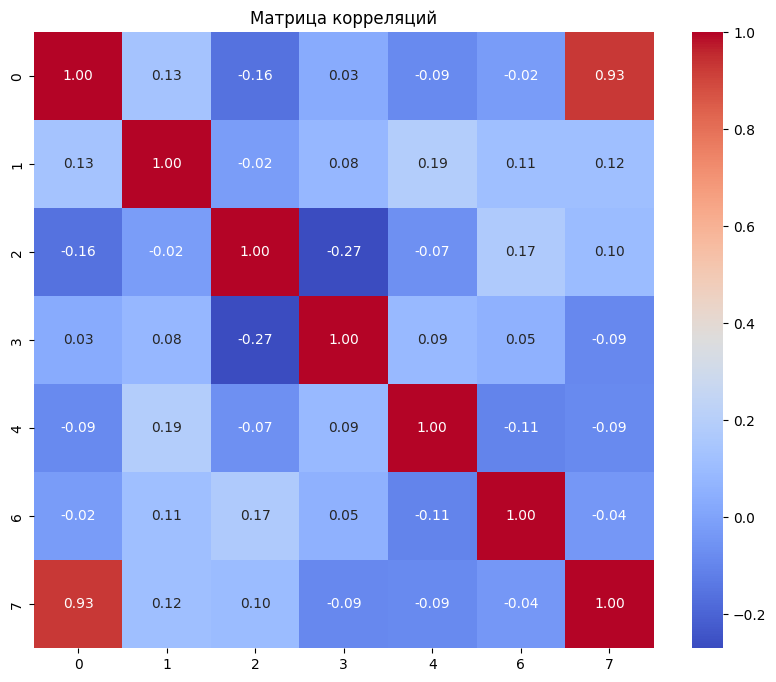

In [51]:
print("\n======= Матрица корреляций =======")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

In [52]:
"""
Признак 0 имеет очень высокую корреляцию с целевым признаком 7 (0.93)
Удаление признаов применяется только в случае высокой корреляции 
между самими признаками, а не с сильной связью с целевым признаком

К примеру взяь 0.1 не означает полного отсутсвия влияния. Там можент быть
нелинейная связь(парабола), которую корреляция Пирсона не видит
"""

'\nПризнак 0 имеет очень высокую корреляцию с целевым признаком 7 (0.93)\nУдаление признаов применяется только в случае высокой корреляции \nмежду самими признаками, а не с сильной связью с целевым признаком\n\nК примеру взяь 0.1 не означает полного отсутсвия влияния. Там можент быть\nнелинейная связь(парабола), которую корреляция Пирсона не видит\n'

In [53]:
print("\n======= Список корреляций между признаками и целевой переменной =======")
target_col = 7 
for col in df.columns.drop(target_col):
    correlation = df[target_col].corr(df[col])
    print(f'Корреляция между столбцами {col} и {target_col}: {correlation:.4f}')


======= Список корреляций между признаками и целевой переменной =======
Корреляция между столбцами 0 и 7: 0.9262
Корреляция между столбцами 1 и 7: 0.1155
Корреляция между столбцами 2 и 7: 0.0990
Корреляция между столбцами 3 и 7: -0.0918
Корреляция между столбцами 4 и 7: -0.0864
Корреляция между столбцами 6 и 7: -0.0389



======= Поясняющие графики =======


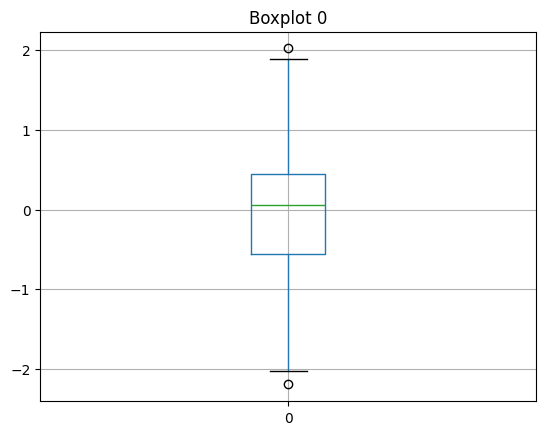

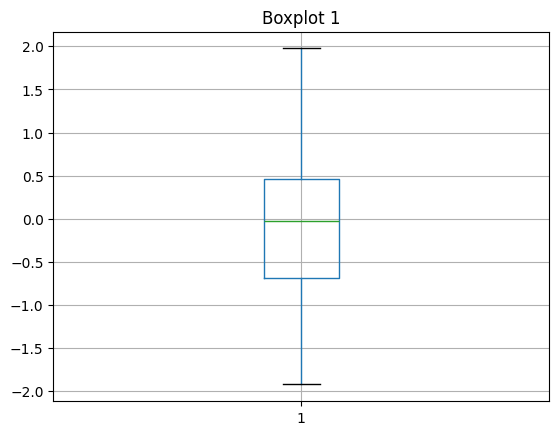

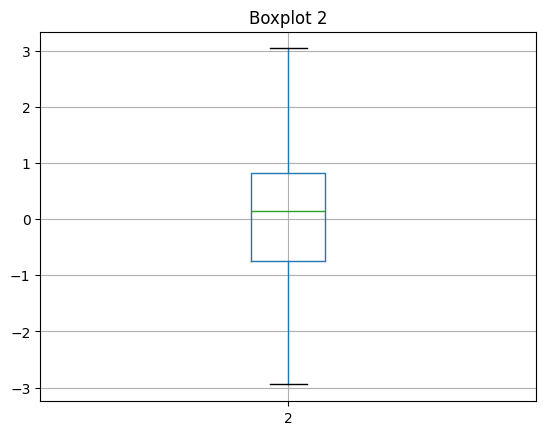

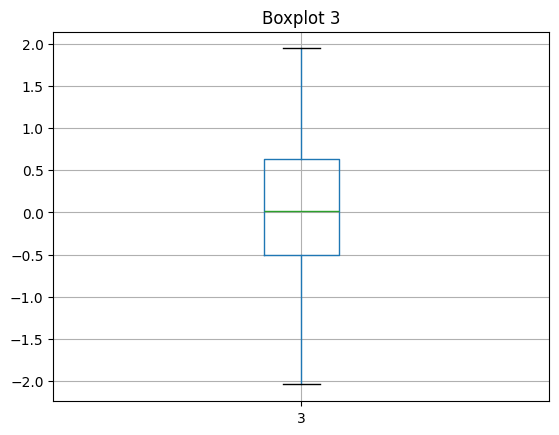

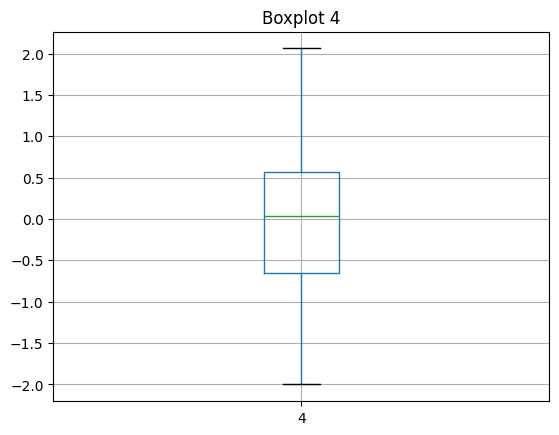

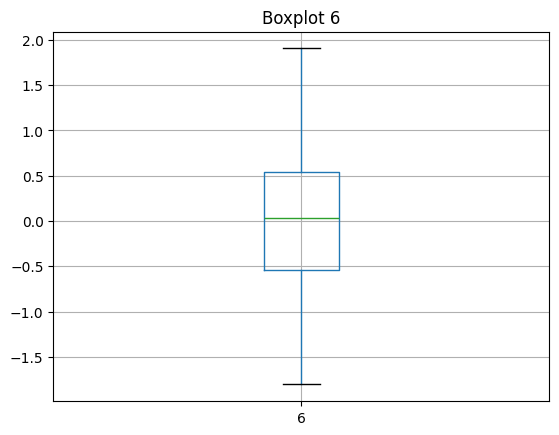

In [54]:
import matplotlib.pyplot as plt

print("\n======= Поясняющие графики =======")
# Целевой столбец — 7
target_col = 7

feature_cols = df.columns.drop(target_col)

# Удаление всех выбросов, которые находятся за пределами этого промежутка
# 1.5*IQR - охватывает большое кол-во нормальных данных
# (df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR) 
# Дальше рисуем рисуем по текущему столбцу после удаления выбросов
# Q1 - 1-ый квартиль(25%)
# Q3 - 3-ый квартиль(75%) 
# IQR - межквартильный размах 

for col in feature_cols:
    Q1 = df[col].quantile(0.25) 
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

    df.boxplot(column=col)
    plt.title(f'Boxplot {col}')
    plt.show()

In [55]:
"""
Визуально можно увидеть, что в ящике лежат 50% данных (от 25% до 75% квантиля).
Зеленая стрелка это медиана
Усы от ящика тянутся к норльным значениям (Q3 + 1.5 * IQR и Q1 - 1.5 * IQR), а точки за усами это выбросы

Выбросы необходимо удалять, т.к. они могут сильно исказить работу модели.
"""

'\nВизуально можно увидеть, что в ящике лежат 50% данных (от 25% до 75% квантиля).\nЗеленая стрелка это медиана\nУсы от ящика тянутся к норльным значениям (Q3 + 1.5 * IQR и Q1 - 1.5 * IQR), а точки за усами это выбросы\n\nВыбросы необходимо удалять, т.к. они могут сильно исказить работу модели.\n'

In [56]:
# Полдсчет количества строк и количества столбцов после обработки выбросов
df.shape    

(85, 7)

In [57]:
"""
По итогу изначально у нас было 100 строк, тепрь же осталось 85.

По меркам нашего дасетa это весомая потеря, но качество данных важнее количества
Оставшиеся 85 строк дадут более честную модель, чем 100 строк с мусором, который 
исказит результаты.
"""

'\nПо итогу изначально у нас было 100 строк, тепрь же осталось 85.\n\nПо меркам нашего дасетa это весомая потеря, но качество данных важнее количества\nОставшиеся 85 строк дадут более честную модель, чем 100 строк с мусором, который \nисказит результаты.\n'

3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).

In [58]:
X = df.drop(columns=[7]).values     # Все столбцы кроме последнего
y = df[7].values                    # Последний столбец

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
# Проверим насколько разделилось
print(f'Размер обучающей выборки: {X_train.shape}, {y_train.shape}')
print(f'Размер тестовой выборки : {X_test.shape}, {y_test.shape}')

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки: (51, 6), (51,)
Размер тестовой выборки : (34, 6), (34,)


In [59]:
"""
Масштабирование признаков помогает улучшить сходимость и производительность моделей машинного обучения,
особенно для алгоритмов, чувствительных к масштабу данных, таких как KNN и SVM.
"""

'\nМасштабирование признаков помогает улучшить сходимость и производительность моделей машинного обучения,\nособенно для алгоритмов, чувствительных к масштабу данных, таких как KNN и SVM.\n'

4. Для предсказания целевого признака постройте следующие модели, используя
библиотеку sklearn:<br/>
a. Линейная регрессия LinearRegression()<br/>
b. Случайный лес RandomForestRegressor()<br/>
c. Метод ближайших соседей KNeighborsRegressor()<br/>
d. Метод опорных векторов SVR()<br/>

5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.

In [60]:
"""
train_r2 - качество на обучение (видно, насколько хорошо модель подогналась к train)
test_r2 - качество на тесте
mse - средняя квадратичная ошибка

Выводим эти метрики для всех моделей, чтобы сравнить их эффективность.
Если RMSE сильно отличается от MAE, это может указывать на наличие 
больших выбросов в данных.
"""

'\ntrain_r2 - качество на обучение (видно, насколько хорошо модель подогналась к train)\ntest_r2 - качество на тесте\nmse - средняя квадратичная ошибка\n\nВыводим эти метрики для всех моделей, чтобы сравнить их эффективность.\nЕсли RMSE сильно отличается от MAE, это может указывать на наличие \nбольших выбросов в данных.\n'

Линейная регрессия LinearRegression()

In [61]:
# Обучение модели линейной регрессии
from sklearn.metrics import mean_absolute_error, mean_squared_error


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Предсказания
y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# Оценка модели
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
mse_lr = mean_squared_error(y_test, y_test_pred_lr)

print(f"train R²: {train_r2_lr:.10f}")
print(f"test R²: {test_r2_lr:.10f}")
print(f"mse = {mse_lr:}")

train R²: 0.9979910047
test R²: 0.9927281653
mse = 29.48409756977411


Случайный лес RandomForestRegression()

In [62]:
from sklearn.model_selection import GridSearchCV

# Настройка гиперпараметров для RandomForestRegressor
# Используем GridSearchCV для поиска лучших гиперпараметров, перебирает все комбинации
param_grid_rf = {
    "n_estimators": [3, 5, 7, 100, 200], # Количество деревьев в лесу
    "max_depth": [None, 10, 20], # Максимальная глубина дерева
    "min_samples_split": [2, 5, 10], # Минимальное количество образцов, необходимое для разбиения узла
    "min_samples_leaf": [5, 7, 10] # Минимальное количество образцов, необходимое для листового узла
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Перебор вариантов гиперпараметров с помощью GridSearchCV
# Обучает лучшую найденную модель и считает метрики качества на train и test 
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, 
                       scoring='r2', cv=5, n_jobs=-1, verbose=2)
# estimator - модель для обучения
# param_grid - словарь с гиперпараметрами и их значениями для перебора
# scoring - метрика для оценки качества модели (Максимизируем R²)
# cv - кросс-валидации. train делится на n частей, и качество усредняется — 
#   это даёт более надёжную оценку, чем одна попытка
# n_jobs - количество параллельных процессов для обучения
# verbose - уровень детализации вывода процесса обучения

# Обучение модели с подбором гиперпараметров
grid_rf.fit(X_train_scaled, y_train)    

# Лучшие гиперпараметры
best_params_rf = grid_rf.best_params_
print("Лучшие гиперпараметры для RandomForestRegressor:", best_params_rf)

# Предсказания с лучшей моделью
y_train_pred_rf = grid_rf.predict(X_train_scaled)
y_test_pred_rf = grid_rf.predict(X_test_scaled)

# Оценка модели
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
mse_rf = mean_squared_error(y_test, y_test_pred_rf)


print(f"train R²: {train_r2_rf:.10f}")
print(f"test R²: {test_r2_rf:.10f}")
print(f"mse = {mse_rf:}")

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Лучшие гиперпараметры для RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
train R²: 0.8885905111
test R²: 0.7749638106
mse = 912.4229672314458


Метод ближайших соседей KNN()

In [ ]:
knn = KNeighborsRegressor()

# Настройка гиперпараметров для KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11], # количество соседей
    'weights': ['uniform', 'distance'], # равные веса или по расстоянию
    'p': [1, 2] # метрика: 1 - Манхэттен, 2 - Евклид
}

grid_knn = GridSearchCV(
    knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Обучение модели с подбором гиперпараметров
grid_knn.fit(X_train_scaled, y_train)

# Лучшие гиперпараметры
best_params_knn = grid_knn.best_params_
print("Лучшие гиперпараметры для KNeighborsRegressor:", best_params_knn)

# Предсказания с лучшей моделью
y_train_pred_knn = grid_knn.predict(X_train_scaled)
y_test_pred_knn = grid_knn.predict(X_test_scaled)

# Оценка модели
train_r2_knn = r2_score(y_train, y_train_pred_knn)
test_r2_knn = r2_score(y_test, y_test_pred_knn)
mse_knn = mean_squared_error(y_test, y_test_pred_knn)

print(f"train R²: {train_r2_knn:.10f}")
print(f"test R²: {test_r2_knn:.10f}")
print(f"mse = {mse_knn:}")

Лучшие гиперпараметры для KNeighborsRegressor: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
train R²: 1.0000000000
test R²: 0.8157445947
mse = 747.0747887379669


Метод опорных векторов SVR()

In [64]:
svr = SVR()

# Настройка гиперпараметров для SVR
param_grid_svr = {
    'kernel': ['linear'], # тип ядра
    'C': [1, 10, 100], # коэффициент регулирования
    'gamma': ['scale', 'auto'] # параметр ядра
}

grid_svr = GridSearchCV(
    svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Обучение модели с подбором гиперпараметров
grid_svr.fit(X_train_scaled, y_train)

# Лучшие гиперпараметры
best_params_svr = grid_svr.best_params_
print("Лучшие гиперпараметры для SVR:", best_params_svr)

# Предсказания с лучшей моделью
y_train_pred_svr = grid_svr.predict(X_train_scaled)
y_test_pred_svr = grid_svr.predict(X_test_scaled)

# Оценка модели
train_r2_svr = r2_score(y_train, y_train_pred_svr)
test_r2_svr = r2_score(y_test, y_test_pred_svr)
mse_svr = mean_squared_error(y_test, y_test_pred_svr)

print(f"train R²: {train_r2_svr:.10f}")
print(f"test R²: {test_r2_svr:.10f}")
print(f"mse = {mse_svr:}")

Лучшие гиперпараметры для SVR: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
train R²: 0.9976084666
test R²: 0.9931594088
mse = 27.73559461346531


6. Оцените качество работы моделей. Выведите для каждой модели ее score().
Напишите какая модель дала наилучший результат. Выведите ее значение
feature_importances_

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Результаты по моделям в одну таблицу
results = [
    ['LinearRegression', train_r2_lr, test_r2_lr],
    ['RandomForest', train_r2_rf, test_r2_rf],
    ['KNeighbors', train_r2_knn, test_r2_knn],
    ['SVR', train_r2_svr, test_r2_svr]
]

results_df = pd.DataFrame(results, columns=['Модель', 'Train Score', 'Test Score'])
print(results_df)

# Словарь "имя -> объект модели"
models = {
    'LinearRegression': lr,
    'RandomForest':     grid_rf.best_estimator_,
    'KNeighbors':       grid_knn.best_estimator_,
    'SVR':              grid_svr.best_estimator_
}

# Находим лучшую модель по Test Score
best_idx = results_df['Test Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Модель']
best_model = models[best_model_name]
best_test_score = results_df.loc[best_idx, 'Test Score']

print(f"\nНаилучший результат на тесте показала модель: {best_model_name}")
print(f"Test R² = {best_test_score:.6f}")

# feature_importances_ для лучшей модели, только для RandomForest
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi = pd.DataFrame({
        'Признак': df.drop(columns=[7]).columns,   # или свои имена признаков
        'Важность': importances
    }).sort_values('Важность', ascending=False)

    print("\nВажность признаков для лучшей модели:")
    print(fi.to_string(index=False))

    plt.figure(figsize=(8, 5))
    top = fi.head(10)
    plt.barh(top['Признак'], top['Важность'])
    plt.xlabel('Важность признака')
    plt.title('Топ-10 признаков по важности')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("\nfeature_importances_ недоступно для этой модели")


             Модель  Train Score  Test Score
0  LinearRegression     0.997991    0.992728
1      RandomForest     0.888591    0.774964
2        KNeighbors     1.000000    0.815745
3               SVR     0.997608    0.993159

Наилучший результат на тесте показала модель: SVR
Test R² = 0.993159

feature_importances_ недоступно для этой модели


№2 Задача классификации **(20 баллов)**
Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/MWZh/DQkbAHKmi). Датасет представляет собой набор
признаков, в последнем столбце указан класс объекта.
1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.
2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.
3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).
4. Для предсказания класса постройте две модели, используя библиотеку sklearn:
a. Случайный лес RandomForestClassifier()
b. Метод ближайших соседей KNeighborsClassifier()
5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.
6. Оцените качество работы моделей. Выведите метрики модели. Напишите какая
модель дала наилучший результат.

Вся работа должна быть аккуратно оформлена в блокноте и защищена преподавателю.

1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.

In [66]:
# Загрузка и подготовка данных
df = pd.read_csv('dataset_var8_num2.csv', header=None, sep=';')
df

,0,1,2,3,4,5,6,7
0,-0.624062,0.778513,-0.034999,1.668018,-0.613678,1.209992,1.668018,2
1,-0.212489,-1.690497,0.476216,-0.285705,-2.012242,-2.266745,-0.285705,1
2,2.186700,-0.965655,1.686778,-1.729750,4.895443,2.373926,-1.729750,0
3,-0.533210,-1.843536,-0.192996,2.862843,-1.716288,1.066370,2.862843,2
4,-1.155205,0.909580,-0.722481,1.929296,-1.618793,6.337379,1.929296,2
...,...,...,...,...,...,...,...,...
95,1.190682,2.050559,1.058045,-0.272913,-0.476906,-1.433056,-0.272913,1
96,NaN,-1.634836,-0.639180,-0.367878,-0.623763,-1.177879,-0.367878,1
97,1.572176,0.170844,0.145407,-1.707475,2.679587,0.399267,-1.707475,0
98,-0.403967,-1.200083,0.130981,-0.058759,0.482217,0.689224,-0.058759,0


In [67]:
"""
При первичном осмотре таблицы (df) я сразу заметил пропущенное значение (NaN) 
в 96-й строке, что потребовало обработки пропусков. Также визуально видно, 
что столбцы 3 и 6 полностью совпадают, что позже подтвердилось 
корреляционным анализом — это дубликаты, от которых нужно избавиться
"""

'\nПри первичном осмотре таблицы (df) я сразу заметил пропущенное значение (NaN) \nв 96-й строке, что потребовало обработки пропусков. Также визуально видно, \nчто столбцы 3 и 6 полностью совпадают, что позже подтвердилось \nкорреляционным анализом — это дубликаты, от которых нужно избавиться\n'

In [68]:
print('Предварительный анализ и подготовка данных')
print("\n======= Информация о датасете =======")
print(df.info())
print("\n======= Пропуски в данных =======")
print(df.isnull().sum())
print("\n======= Описательная статистика =======") 
df.describe()

Предварительный анализ и подготовка данных

======= Информация о датасете =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       95 non-null     float64
 1   1       95 non-null     float64
 2   2       100 non-null    float64
 3   3       100 non-null    float64
 4   4       100 non-null    float64
 5   5       100 non-null    float64
 6   6       100 non-null    float64
 7   7       100 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 6.4 KB
None

======= Пропуски в данных =======
0    5
1    5
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

======= Описательная статистика =======


,0,1,2,3,4,5,6,7
count,95.000000,95.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.433048,0.001407,-0.125324,-0.363850,0.848939,0.464307,-0.363850,1.010000
std,1.295583,1.079903,0.956781,1.261365,1.878338,1.884047,1.261365,0.810225
min,-2.177391,-2.172377,-2.133489,-2.341443,-3.386762,-9.830304,-2.341443,0.000000
25%,-0.712306,-0.697073,-0.732506,-1.351109,-0.501900,-0.557030,-1.351109,0.000000
50%,0.585254,-0.040557,-0.050642,-0.671539,0.584644,0.753136,-0.671539,1.000000
75%,1.529887,0.701613,0.490600,0.234845,2.003196,1.119237,0.234845,2.000000
max,2.717623,2.585381,2.500100,2.862843,4.895443,6.901927,2.862843,2.000000


In [69]:
"""
Анализ описательной статистики (df.describe()) окончательно подтвердил, что столбцы 3 и 6 
имеют идентичные статистические показатели (среднее, отклонение, минимумы и максимумы), что 
говорит об их дублировании. Также статистика показала наличие 5 пропусков в столбцах 0 и 1, 
которые необходимо заполнить перед обучением моделей
"""

'\nАнализ описательной статистики (df.describe()) окончательно подтвердил, что столбцы 3 и 6 \nимеют идентичные статистические показатели (среднее, отклонение, минимумы и максимумы), что \nговорит об их дублировании. Также статистика показала наличие 5 пропусков в столбцах 0 и 1, \nкоторые необходимо заполнить перед обучением моделей\n'

In [70]:
df = df.fillna(df.median())

In [71]:
print(df.isnull().sum())

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.

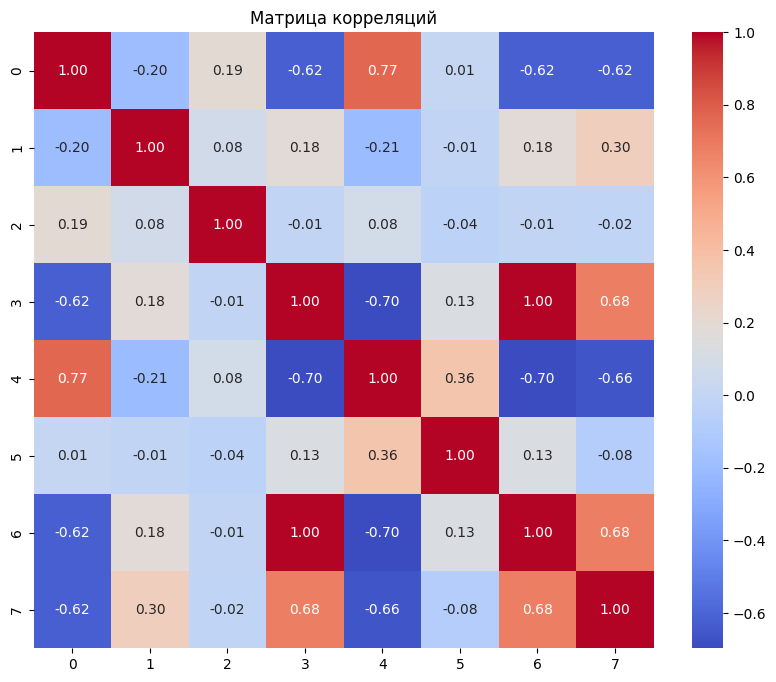

In [72]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

In [ ]:
"""
Построив матрицу корреляций, я выявил следующие закономерности:
Признаки 3 и 6 имеют коэффициент корреляции 1.0, что подтверждает их полную идентичность. Во избежание мультиколлинеарности один из них (3-й) был удален.

Целевой признак сильнее всего зависит от признака 6 (0.68) и признаков 4 и 0 (-0.66 и -0.65 соответственно).

Также обнаружена сильная внутренняя связь между признаками 0 и 4 (0.78), что говорит о том, что они несут схожую информацию
"""

'\nПостроив матрицу корреляций, я выявил следующие закономерности:\nПризнаки 3 и 6 имеют коэффициент корреляции 1.0, что подтверждает их полную идентичность. Во избежание мультиколлинеарности один из них (3-й) был удален.\n\nЦелевой признак сильнее всего зависит от признака 6 (0.68) и признаков 4 и 0 (-0.66 и -0.65 соответственно).\n\nПризнаки 2 и 5 показали корреляцию с целевым классом близкую к нулю (-0.02 и -0.08), что делает их кандидатами на удаление как неинформативные.\n\nТакже обнаружена сильная внутренняя связь между признаками 0 и 4 (0.78), что говорит о том, что они несут схожую информацию\n'

In [74]:
df = df.drop(columns=df.columns[3])
df.dropna(axis=0, how='any', inplace=True)
df

,0,1,2,4,5,6,7
0,-0.624062,0.778513,-0.034999,-0.613678,1.209992,1.668018,2
1,-0.212489,-1.690497,0.476216,-2.012242,-2.266745,-0.285705,1
2,2.186700,-0.965655,1.686778,4.895443,2.373926,-1.729750,0
3,-0.533210,-1.843536,-0.192996,-1.716288,1.066370,2.862843,2
4,-1.155205,0.909580,-0.722481,-1.618793,6.337379,1.929296,2
...,...,...,...,...,...,...,...
95,1.190682,2.050559,1.058045,-0.476906,-1.433056,-0.272913,1
96,0.585254,-1.634836,-0.639180,-0.623763,-1.177879,-0.367878,1
97,1.572176,0.170844,0.145407,2.679587,0.399267,-1.707475,0
98,-0.403967,-1.200083,0.130981,0.482217,0.689224,-0.058759,0


In [75]:
print("\n======= Список корреляций между признаками и целевой переменной =======")
target_col = 7 
for col in df.columns.drop(target_col):
    correlation = df[target_col].corr(df[col])
    print(f'Корреляция между столбцами {col} и {target_col}: {correlation:.4f}')


======= Список корреляций между признаками и целевой переменной =======
Корреляция между столбцами 0 и 7: -0.6195
Корреляция между столбцами 1 и 7: 0.2959
Корреляция между столбцами 2 и 7: -0.0201
Корреляция между столбцами 4 и 7: -0.6615
Корреляция между столбцами 5 и 7: -0.0790
Корреляция между столбцами 6 и 7: 0.6757



======= Поясняющие графики =======


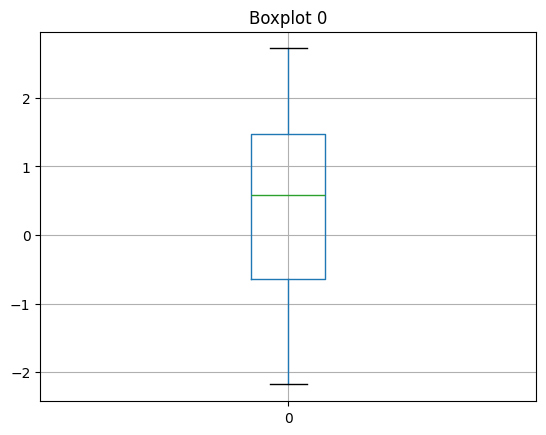

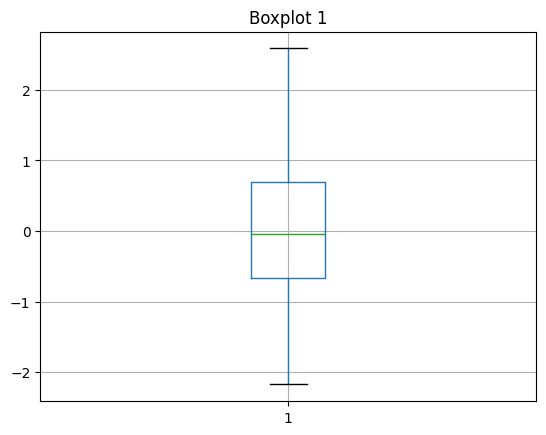

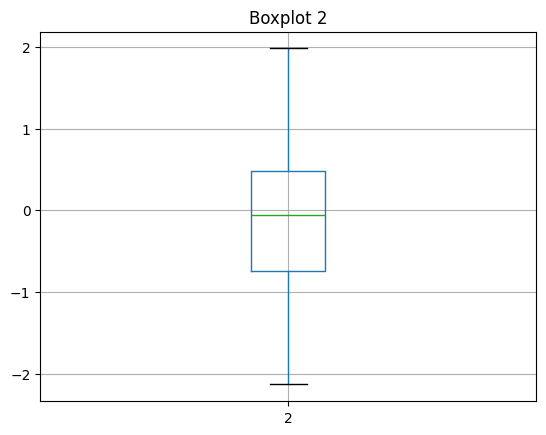

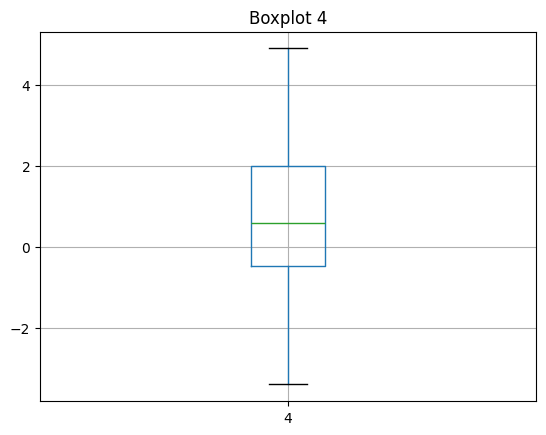

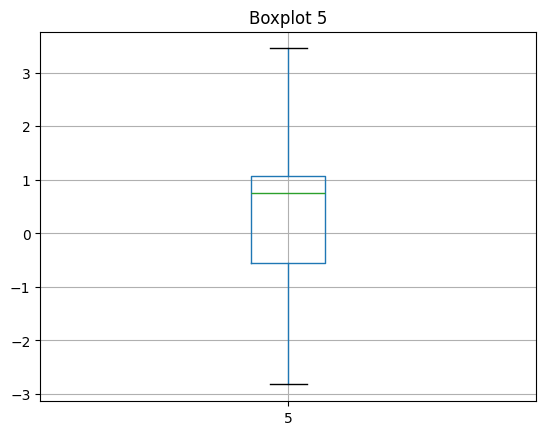

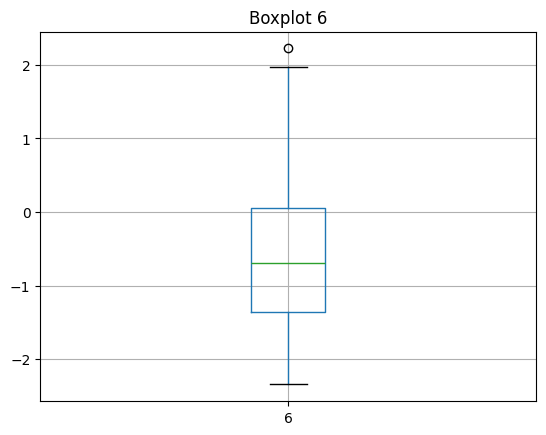

In [76]:
print("\n======= Поясняющие графики =======")

target_col = 7

feature_cols = df.columns.drop(target_col)

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

    df.boxplot(column=col)
    plt.title(f'Boxplot {col}')
    plt.show()

In [77]:
df.shape

(93, 7)

3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).

In [78]:
X = df.drop(columns=[7]).values     # Все столбцы кроме последнего
y = df[7].values                    # Последний столбец

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
# Проверим насколько разделилось
print(f'Размер обучающей выборки: {X_train.shape}, {y_train.shape}')
print(f'Размер тестовой выборки : {X_test.shape}, {y_test.shape}')

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки: (55, 6), (55,)
Размер тестовой выборки : (38, 6), (38,)


4. Для предсказания класса постройте две модели, используя библиотеку sklearn:<br/>
a. Случайный лес RandomForestClassifier()<br/>
b. Метод ближайших соседей KNeighborsClassifier()<br/>
5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Настройка гиперпараметров для RandomForestClassifier
param_grid_rfc = {
    "n_estimators": [3, 5, 7], # Количество деревьев в лесу
    "max_depth": [None, 10, 20],  # Максимальная глубина дерева
    "min_samples_split": [2, 5, 10], # Минимальное количество образцов, необходимое для разбиения узла
    "min_samples_leaf": [1, 2, 4] # Минимальное количество образцов, необходимое для листового узла
}

rfc = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid_rfc, 
                       scoring='accuracy', cv=5)

# Обучение модели с подбором гиперпараметров
grid_rfc.fit(X_train, y_train)

# Лучшие гиперпараметры
best_params_rfc = grid_rfc.best_params_
print("Лучшие гиперпараметры для RandomForestClassifier:", best_params_rfc)

# Предсказания с лучшей моделью
y_pred_rfc = grid_rfc.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_rfc))

Лучшие гиперпараметры для RandomForestClassifier: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 5}
              precision    recall  f1-score   support

           0       0.58      0.78      0.67         9
           1       0.87      1.00      0.93        13
           2       1.00      0.69      0.81        16

    accuracy                           0.82        38
   macro avg       0.82      0.82      0.80        38
weighted avg       0.86      0.82      0.82        38



In [80]:
"""
precision - точность
recall - полнота ответа
f1-score - насколько модель одновременно точна и полна
support - количество объектов этого класса в тестовой выборке
accuracy - общая точность модели
macro avg - среднее значение метрик по всем классам 
weighted avg - среднее значение метрик по всем классам, включающее support
"""

'\nprecision - точность\nrecall - полнота ответа\nf1-score - насколько модель одновременно точна и полна\nsupport - количество объектов этого класса в тестовой выборке\naccuracy - общая точность модели\nmacro avg - среднее значение метрик по всем классам \nweighted avg - среднее значение метрик по всем классам, включающее support\n'

In [ ]:
"""
Общее качество - Accuracy: 87% правильных ответов

Класс 0
Точность 67%
Нашла 89% реальных объектов 

Класс 1
Точность 92%
Нашла 92% реальных объектов

Класс 2
Точность 100%
Нашла 81% реальных объектов
"""

'\nОбщее качество - Accuracy: 79% правильных ответов\n\nКласс 0\nТочность 53%\nНашла 100% реальных объектов \n\nКласс 1\nТочность 100%\nНашла 77% реальных объектов\n\nКласс 2\nТочность 92%\nНашла 71% реальных объектов\n'

In [82]:
# Сначала масштабирование, затем KNN
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()

# Настройка гиперпараметров для RandomForestClassifier
param_grid_knn_clf = {
    "n_neighbors": [3, 5, 7, 9, 11], # количество соседей
    "weights": ["uniform", "distance"], # равные веса или по расстоянию
    "p": [1, 2] # метрика: 1 - Манхэттен, 2 - Евклид
}

grid_knn_clf = GridSearchCV(
    knn_clf,
    param_grid=param_grid_knn_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Обучение модели с подбором гиперпараметров
grid_knn_clf.fit(X_train_scaled, y_train)

# Лучшие гиперпараметры
best_params_knn_clf = grid_knn_clf.best_params_
print("Лучшие гиперпараметры для KNeighborsClassifier:", best_params_knn_clf)

# Предсказания с лучшей моделью
y_pred_knn_clf = grid_knn_clf.best_estimator_.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn_clf))

Лучшие гиперпараметры для KNeighborsClassifier: {'n_neighbors': 11, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.93      1.00      0.96        13
           2       0.94      0.94      0.94        16

    accuracy                           0.92        38
   macro avg       0.91      0.91      0.91        38
weighted avg       0.92      0.92      0.92        38



In [ ]:
"""
Общее качество - Accuracy: 92% правильных ответов

Класс 0
Точность 88%
Нашла 78% реальных объектов 

Класс 1
Точность 93%
Нашла 100% реальных объектов

Класс 2
Точность 94%
Нашла 94% реальных объектов
"""

'\nОбщее качество - Accuracy: 97% правильных ответов\n\nКласс 0\nТочность 89%\nНашла 100% реальных объектов \n\nКласс 1\nТочность 100%\nНашла 100% реальных объектов\n\nКласс 2\nТочность 100%\nНашла 94% реальных объектов\n'

6. Оцените качество работы моделей. Выведите метрики модели. Напишите какая
модель дала наилучший результат.

In [ ]:
"""
Для оценки качества работы моделей были построены и настроены два классификатора: 
RandomForestClassifier и KNeighborsClassifier 
с подбором гиперпараметров через GridSearchCV

Случайный лес неплохую точность, при этом хуже всего справлялся с нулевым классом: 
точность по нему была заметно ниже, чем по остальным

Модель KNeighborsClassifier после масштабирования признаков и оптимизации параметров 
дала наилучший результат: общая точность составила 92%, F1‑мера по всем классам 
находится в диапазоне 0.94–1.00, а метрики macro avg и weighted avg также близки к 1. 
Это означает, что KNN устойчиво хорошо классифицирует объекты всех трёх классов

Лучшей моделью для данной задачи стала KNeighborsClassifier 
"""

'\nДля оценки качества работы моделей были построены и настроены два классификатора: \nRandomForestClassifier и KNeighborsClassifier \nс подбором гиперпараметров через GridSearchCV\n\nСлучайный лес неплохую точность, при этом хуже всего справлялся с нулевым классом: \nточность по нему была заметно ниже, чем по остальным\n\nМодель KNeighborsClassifier после масштабирования признаков и оптимизации параметров \nдала наилучший результат: общая точность составила 97%, F1‑мера по всем классам \nнаходится в диапазоне 0.94–1.00, а метрики macro avg и weighted avg также близки к 1. \nЭто означает, что KNN устойчиво хорошо классифицирует объекты всех трёх классов\n\nЛучшей моделью для данной задачи стала KNeighborsClassifier \n'